In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/AI_Forensic_Project"

folders = [
    "raw_data/CelebA",
    "raw_data/StyleGAN",
    "raw_data/FaceForensics++",
    "raw_data/CASIA",
    "dataset/real",
    "dataset/gan",
    "dataset/deepfake",
    "dataset/edited",
    "outputs",
    "test_images",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Complete folder structure created successfully.")

Complete folder structure created successfully.


In [ ]:
!find "/content/drive/MyDrive/AI_Forensic_Project/raw_data" -maxdepth 2 -type d


/content/drive/MyDrive/AI_Forensic_Project/raw_data
/content/drive/MyDrive/AI_Forensic_Project/raw_data/CelebA
/content/drive/MyDrive/AI_Forensic_Project/raw_data/StyleGAN
/content/drive/MyDrive/AI_Forensic_Project/raw_data/FaceForensics++
/content/drive/MyDrive/AI_Forensic_Project/raw_data/CASIA
/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset
/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/deepfake
/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/edited
/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/gan
/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/real


In [ ]:
!ls "/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/real" | head

000001.jpg
000002.jpg
000003.jpg
000004.jpg
000005.jpg
000006.jpg
000007.jpg
000008.jpg
000009.jpg
000010.jpg


In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive/AI_Forensic_Project"

source_map = {
    "real": "raw_data/forensic-dataset/real",
    "gan": "raw_data/forensic-dataset/gan",
    "deepfake": "raw_data/forensic-dataset/deepfake",
    "edited": "raw_data/forensic-dataset/edited",
}

for cls, src_rel in source_map.items():
    src = os.path.join(base_path, src_rel)
    dst = os.path.join(base_path, "dataset", cls)
    os.makedirs(dst, exist_ok=True)

    for fname in os.listdir(src):
        src_file = os.path.join(src, fname)
        dst_file = os.path.join(dst, fname)
        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)

print("Files copied to final dataset folders.")

Files copied to final dataset folders.


In [ ]:
import os

for cls in ["real", "gan", "deepfake", "edited"]:
    folder = f"/content/drive/MyDrive/AI_Forensic_Project/raw_data/forensic-dataset/{cls}"
    if os.path.isdir(folder):
        count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
        status = "present" if count > 0 else "empty"
        print(cls, status, count)
    else:
        print(cls, "missing")

real present 5005
gan present 5004
deepfake present 5000
edited present 7491


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 762.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import os
import shutil
import random

random.seed(42)

base_path = "/content/drive/MyDrive/AI_Forensic_Project"
src_base = os.path.join(base_path, "raw_data", "forensic-dataset")
dst_base = os.path.join(base_path, "balanced_dataset")

classes = ["real", "gan", "deepfake", "edited"]
target_counts = {
    "real": 5000,
    "gan": 5000,
    "deepfake": 5000,
    "edited": 5000
}

os.makedirs(dst_base, exist_ok=True)

for cls in classes:
    src_dir = os.path.join(src_base, cls)
    dst_dir = os.path.join(dst_base, cls)
    os.makedirs(dst_dir, exist_ok=True)

    files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
    random.shuffle(files)

    selected = files[:target_counts[cls]]

    for fname in selected:
        shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))

    print(f"{cls}: copied {len(selected)} files")

In [ ]:
classes = ["real", "gan", "deepfake", "edited"]
for cls in classes:
    folder = os.path.join(dst_base, cls)
    count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
    print(cls, count)

In [ ]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_path = "/content/drive/MyDrive/AI_Forensic_Project"
dataset_path = os.path.join(base_path, "balanced_dataset")
output_path = os.path.join(base_path, "outputs")

os.makedirs(output_path, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

with open(os.path.join(output_path, "class_names.json"), "w") as f:
    json.dump(class_names, f)

print("Saved class_names.json")

Found 20000 files belonging to 4 classes.
Using 16000 files for training.
Found 20000 files belonging to 4 classes.
Using 4000 files for validation.
Classes: ['deepfake', 'edited', 'gan', 'real']
Saved class_names.json


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1),
    ModelCheckpoint(
        os.path.join(output_path, "efficientnetb0_best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1798s 2s/step - accuracy: 0.9398 - loss: 0.2077 - val_accuracy: 0.9385 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 2/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1630s 1s/step - accuracy: 0.9709 - loss: 0.0941 - val_accuracy: 0.9567 - val_loss: 0.1179 - learning_rate: 0.0010
Epoch 3/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1657s 2s/step - accuracy: 0.9750 - loss: 0.0784 - val_accuracy: 0.9645 - val_loss: 0.1016 - learning_rate: 0.0010
Epoch 4/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1635s 2s/step - accuracy: 0.9777 - loss: 0.0681 - val_accuracy: 0.9638 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 5/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1714s 2s/step - accuracy: 0.9804 - loss: 0.0627 - val_accuracy: 0.9707 - val_loss: 0.0813 - learning_rate: 0.0010
Epoch 6/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1682s 2s/step - accuracy: 0.9817 - loss: 0.0566 - val_accuracy: 0.9695 - val_loss: 0.0847 - learning_rate: 0.0010
Epoch 7/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9819

In [ ]:
base_model.trainable = True
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1),
    ModelCheckpoint(
        os.path.join(output_path, "efficientnetb0_best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=4,
    callbacks=callbacks
)

Epoch 1/4
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1509s 1s/step - accuracy: 0.7613 - loss: 0.7482 - val_accuracy: 0.9398 - val_loss: 0.3507 - learning_rate: 1.0000e-05
Epoch 2/4
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1371s 1s/step - accuracy: 0.9389 - loss: 0.2786 - val_accuracy: 0.9630 - val_loss: 0.1512 - learning_rate: 1.0000e-05
Epoch 3/4
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1326s 1s/step - accuracy: 0.9599 - loss: 0.1567 - val_accuracy: 0.9760 - val_loss: 0.0902 - learning_rate: 1.0000e-05
Epoch 4/4


In [ ]:
import os
import json
import tensorflow as tf

# Paths
base_path = "/content/drive/MyDrive/AI_Forensic_Project"
output_path = os.path.join(base_path, "outputs")
dataset_path = os.path.join(base_path, "balanced_dataset")

model_path = os.path.join(output_path, "efficientnetb0_best_model.keras")
class_names_path = os.path.join(output_path, "class_names.json")

# Recreate validation dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Load saved model
model = tf.keras.models.load_model(model_path)

# Load class names
with open(class_names_path, "r") as f:
    class_names = json.load(f)

# Evaluate
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

# Optional: show model summary
model.summary()

Found 20000 files belonging to 4 classes.
Using 4000 files for validation.
250/250 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.9760 - loss: 0.0902
Validation Loss: 0.09023719280958176
Validation Accuracy: 0.9760000109672546


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,057,265 (26.92 MB)

 Trainable params: 1,501,284 (5.73 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,002,570 (11.45 MB)

              precision    recall  f1-score   support

    deepfake       0.98      0.99      0.99       994
      edited       0.99      0.97      0.98       962
         gan       0.94      1.00      0.97      1002
        real       0.99      0.95      0.97      1042

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



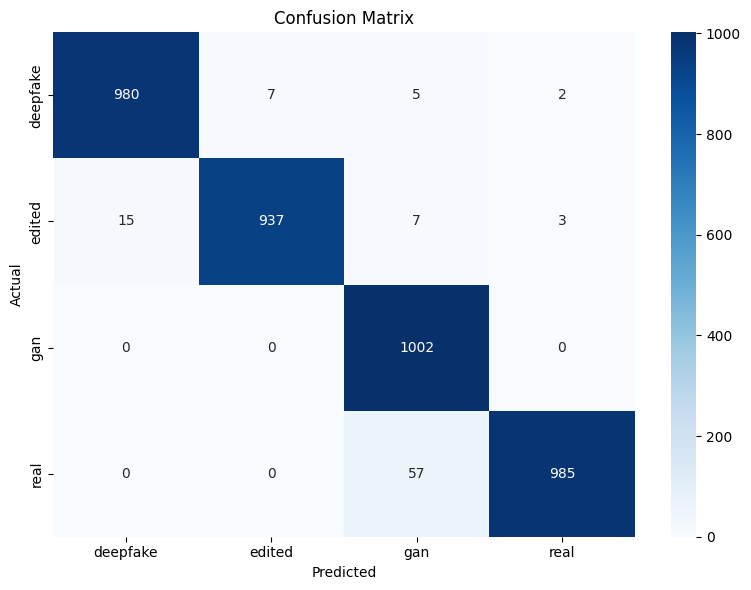

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

real.jpg -> Predicted: real (76.11%)
  deepfake: 0.32%
  edited: 0.46%
  gan: 23.11%
  real: 76.11%
----------------------------------------
gan.jpg -> Predicted: gan (99.25%)
  deepfake: 0.04%
  edited: 0.06%
  gan: 99.25%
  real: 0.65%
----------------------------------------
deepfake.jpg -> Predicted: deepfake (79.59%)
  deepfake: 79.59%
  edited: 19.77%
  gan: 0.21%
  real: 0.43%
----------------------------------------
edited.jpg -> Predicted: edited (96.41%)
  deepfake: 2.56%
  edited: 96.41%
  gan: 0.86%
  real: 0.17%
----------------------------------------


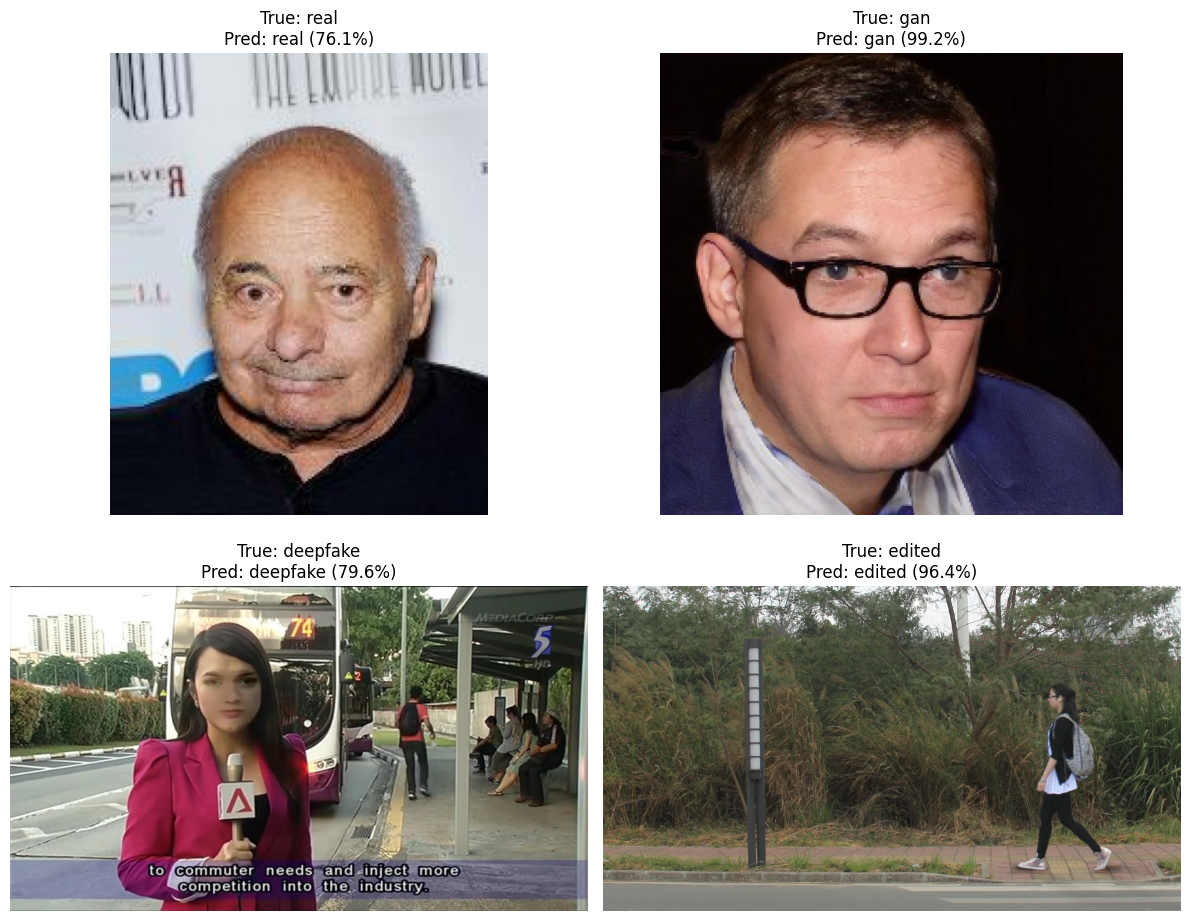

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Paths
base_path = "/content/drive/MyDrive/AI_Forensic_Project"
model_path = os.path.join(base_path, "outputs", "efficientnetb0_best_model.keras")
class_names_path = os.path.join(base_path, "outputs", "class_names.json")
test_dir = os.path.join(base_path, "test_images")

# Load model and class names
model = tf.keras.models.load_model(model_path)

with open(class_names_path, "r") as f:
    class_names = json.load(f)

# Test files in your folder
test_files = ["real.jpg", "gan.jpg", "deepfake.jpg", "edited.jpg"]

# Preprocessing function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = float(np.max(preds)) * 100
    return pred_class, confidence, preds

# Plot and print results
plt.figure(figsize=(12, 10))

for i, fname in enumerate(test_files, 1):
    img_path = os.path.join(test_dir, fname)
    pred_class, confidence, preds = predict_image(img_path)

    plt.subplot(2, 2, i)
    plt.imshow(image.load_img(img_path))
    plt.title(f"True: {fname.replace('.jpg','')}\nPred: {pred_class} ({confidence:.1f}%)")
    plt.axis("off")

    print(f"{fname} -> Predicted: {pred_class} ({confidence:.2f}%)")
    for cls, prob in zip(class_names, preds):
        print(f"  {cls}: {prob*100:.2f}%")
    print("-" * 40)

plt.tight_layout()
plt.show()